# Week 7 — Error Analysis & Streamlit App
**Project:** Drug Side Effect Predictor  
**Context:** Week 6 returned PASS — LR (C=5.0, threshold=0.50) achieved micro-F1 = 0.4455 on the test set, beating the frequency baseline by +0.0468 using proper CV-tuned hyperparameters with no test-set leakage.

**What this notebook does:**
1. Builds a `predict(drug_name)` function that performs local lookup → feature retrieval → `lr_tuned` inference → ranked side effects with scores
2. Runs per-ATC-class error analysis (1-character therapeutic groups) to understand where the model succeeds and fails
3. Inspects the 5 worst-predicted test drugs with automated diagnosis
4. Produces `app.py` — a minimal Streamlit interface wrapping `predict()`
5. Writes README and project reflection

**Inputs (from previous weeks):**
- `data/processed/X_train.npz`, `X_test.npz`, `y_train.npy`, `y_test.npy`
- `data/processed/train_index.csv`, `test_index.csv`, `label_names.csv`
- `data/splits/train.csv`, `test.csv` — raw attributes (ATC codes + indications text) needed for predict()
- `models/lr_tuned.pkl` — final tuned model from Week 6
- `models/encoders/mlb_atc.pkl`, `tfidf_indications.pkl` — fitted encoders from Week 3

**Key decisions locked in:**
- `predict()` works over SIDER drugs only (local lookup); unknown drugs return a clean error message
- Output: all predictions above threshold=0.50, ranked by score; top-20 shown by default in app
- ATC error analysis at 1-character level (14 main therapeutic groups)
- Per-drug failure: worst 5 by micro-F1, with automated diagnosis (ATC familiarity + training similarity)

## Setup

In [20]:
import os
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
import joblib

warnings.filterwarnings('ignore', category=UserWarning)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE      = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\\"
SPLITS    = BASE + r"data\splits\\"
PROCESSED = BASE + r"data\processed\\"
MODELS    = BASE + r"models\\"
ENCODERS  = BASE + r"models\encoders\\"
FIGURES   = BASE + r"figures\\"

for folder in [MODELS, FIGURES]:
    os.makedirs(folder, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## Load all artifacts

In [21]:
# ── Feature matrices & labels ──────────────────────────────────────────────────
X_train = sparse.load_npz(PROCESSED + 'X_train.npz')
X_test  = sparse.load_npz(PROCESSED + 'X_test.npz')
y_train = np.load(PROCESSED + 'y_train.npy')
y_test  = np.load(PROCESSED + 'y_test.npy')

# ── Index files ────────────────────────────────────────────────────────────────
train_index = pd.read_csv(PROCESSED + 'train_index.csv')
test_index  = pd.read_csv(PROCESSED + 'test_index.csv')
label_names = pd.read_csv(PROCESSED + 'label_names.csv')['side_effect'].tolist()

# ── Raw split files (needed for predict() attribute retrieval) ─────────────────
train_df = pd.read_csv(SPLITS + 'train.csv')
test_df  = pd.read_csv(SPLITS + 'test.csv')
all_df   = pd.concat([train_df, test_df], ignore_index=True)

# ── Encoders ───────────────────────────────────────────────────────────────────
mlb   = joblib.load(ENCODERS + 'mlb_atc.pkl')
tfidf = joblib.load(ENCODERS + 'tfidf_indications.pkl')

# ── Tuned model ────────────────────────────────────────────────────────────────
model = joblib.load(MODELS + 'lr_tuned.pkl')

THRESHOLD = 0.50   # locked from Week 6 CV tuning

print(f'Drugs in full dataset : {len(all_df)}')
print(f'Train / Test          : {len(train_df)} / {len(test_df)}')
print(f'Labels                : {len(label_names)}')
print(f'Threshold             : {THRESHOLD}')

Drugs in full dataset : 1117
Train / Test          : 893 / 224
Labels                : 845
Threshold             : 0.5


---
## Step 7.1 — `predict(drug_name)` function

Full pipeline:
1. **Name lookup** — case-insensitive match against `all_df['drug_name']`
2. **Attribute retrieval** — pull `atc_codes` and `indications_text` for that drug
3. **Feature encoding** — MLB transform on ATC codes + TF-IDF transform on indication text → stack into sparse row
4. **Inference** — `model.predict_proba()` → apply threshold=0.50 → rank by score
5. **Return** — DataFrame of `(side_effect, score)` sorted descending, plus metadata

In [22]:
# Build a name → row lookup (case-insensitive, strip whitespace)
lookup = all_df.copy()
lookup['_name_lower'] = lookup['drug_name'].str.lower().str.strip()
lookup = lookup.set_index('_name_lower')


def predict(drug_name: str, threshold: float = THRESHOLD) -> dict:
    """
    Predict side effects for a drug in the SIDER dataset.

    Parameters
    ----------
    drug_name : str
        Common drug name (case-insensitive). Must be present in the local dataset.
    threshold : float
        Probability threshold; side effects with score >= threshold are returned.
        Defaults to 0.50 (CV-tuned in Week 6).

    Returns
    -------
    dict with keys:
        'found'        : bool — whether the drug was found in the dataset
        'drug_name'    : str  — canonical name as stored in dataset
        'stitch_id'    : str  — STITCH compound identifier
        'predictions'  : pd.DataFrame with columns ['side_effect', 'score']
                         sorted by score descending; empty if not found
        'n_predicted'  : int  — number of side effects above threshold
        'split'        : str  — 'train' | 'test' | 'unknown'
    """
    key = drug_name.lower().strip()

    if key not in lookup.index:
        return {
            'found'       : False,
            'drug_name'   : drug_name,
            'stitch_id'   : None,
            'predictions' : pd.DataFrame(columns=['side_effect', 'score']),
            'n_predicted' : 0,
            'split'       : 'unknown',
        }

    row = lookup.loc[key]
    # If there are duplicate names, take the first
    if isinstance(row, pd.DataFrame):
        row = row.iloc[0]

    canonical_name = row['drug_name']
    stitch_id      = row['stitch_id_flat']

    # Determine train / test split
    if stitch_id in train_index['stitch_id_flat'].values:
        split = 'train'
    elif stitch_id in test_index['stitch_id_flat'].values:
        split = 'test'
    else:
        split = 'unknown'

    # ── Feature encoding ───────────────────────────────────────────────────────
    # ATC codes are stored as a Python list string: "['A10B', 'C09A']"
    raw_atc = row['atc_codes']
    try:
        atc_list = ast.literal_eval(raw_atc) if isinstance(raw_atc, str) else []
    except (ValueError, SyntaxError):
        atc_list = []

    # 3-char subgroup codes (same level MLB was fitted on)
    atc_3char = list({c[:3] for c in atc_list if len(c) >= 3})
    X_atc   = mlb.transform([atc_3char])                         # (1, 82)

    indication = row['indications_text'] if pd.notna(row.get('indications_text')) else ''
    X_tfidf = tfidf.transform([str(indication)])                  # (1, 200)

    X = sparse.hstack([X_atc, X_tfidf], format='csr')            # (1, 282)

    # ── Inference ──────────────────────────────────────────────────────────────
    scores = model.predict_proba(X)[0]                            # (845,)

    # Apply threshold; fall back to top-1 if nothing clears it
    mask = scores >= threshold
    if not mask.any():
        mask[np.argmax(scores)] = True

    results = pd.DataFrame({
        'side_effect': [label_names[i] for i in np.where(mask)[0]],
        'score'      : scores[mask],
    }).sort_values('score', ascending=False).reset_index(drop=True)

    return {
        'found'       : True,
        'drug_name'   : canonical_name,
        'stitch_id'   : stitch_id,
        'predictions' : results,
        'n_predicted' : len(results),
        'split'       : split,
    }


print('predict() defined.')

predict() defined.


In [23]:
# ── Smoke test ────────────────────────────────────────────────────────────────
for test_name in ['ibuprofen', 'lorazepam', 'notadrug_xyz']:
    result = predict(test_name)
    if result['found']:
        print(f"\n{result['drug_name']}  [{result['split']}]  →  {result['n_predicted']} side effects predicted")
        print(result['predictions'].head(10).to_string(index=False))
    else:
        print(f"\n'{test_name}' → NOT FOUND in dataset")


ibuprofen  [train]  →  247 side effects predicted
             side_effect    score
                  Nausea 0.992317
         Hepatic failure 0.980795
            Crystalluria 0.973736
                Jaundice 0.969660
Stevens-Johnson syndrome 0.964703
               Dyspepsia 0.963597
     Erythema multiforme 0.960302
                Vomiting 0.958162
                    Rash 0.957054
      Anaphylactic shock 0.956888

lorazepam  [train]  →  46 side effects predicted
                 side_effect    score
      Pulmonary hypertension 0.965884
       Pulmonary haemorrhage 0.930345
                      Anuria 0.930063
                    Gangrene 0.871628
 Arrhythmia supraventricular 0.841882
Lacrimal structural disorder 0.781140
                Coagulopathy 0.776887
                Crystalluria 0.774310
        Ulcerative keratitis 0.766099
                  Thrombosis 0.739728

'notadrug_xyz' → NOT FOUND in dataset


In [24]:
# Save predict() and all dependencies as a self-contained module for the app
# (The app will import from predict_utils.py rather than re-defining everything)

predict_utils_code = '''
"""predict_utils.py — Drug Side Effect Predictor inference module.

Used by app.py (Streamlit) and any downstream consumer.
Loads all artifacts once at import time.

DISCLAIMER: Predictions are for educational/portfolio purposes only.
This tool must not be used to inform real medical decisions.
"""

import ast
import numpy as np
import pandas as pd
from scipy import sparse
import joblib
from pathlib import Path

# ── Resolve paths relative to this file ───────────────────────────────────────
_HERE      = Path(__file__).resolve().parent
PROCESSED  = _HERE / "data" / "processed"
SPLITS     = _HERE / "data" / "splits"
MODELS     = _HERE / "models"
ENCODERS   = _HERE / "models" / "encoders"

THRESHOLD  = 0.50   # CV-tuned in Week 6

# ── Load all artifacts once ────────────────────────────────────────────────────
train_index = pd.read_csv(PROCESSED / "train_index.csv")
test_index  = pd.read_csv(PROCESSED / "test_index.csv")
label_names = pd.read_csv(PROCESSED / "label_names.csv")["side_effect"].tolist()

train_df    = pd.read_csv(SPLITS / "train.csv")
test_df     = pd.read_csv(SPLITS / "test.csv")
all_df      = pd.concat([train_df, test_df], ignore_index=True)

mlb         = joblib.load(ENCODERS / "mlb_atc.pkl")
tfidf       = joblib.load(ENCODERS / "tfidf_indications.pkl")
model       = joblib.load(MODELS   / "lr_tuned.pkl")

_lookup = all_df.copy()
_lookup["_name_lower"] = _lookup["drug_name"].str.lower().str.strip()
_lookup = _lookup.set_index("_name_lower")


def predict(drug_name: str, threshold: float = THRESHOLD) -> dict:
    """Predict side effects for a SIDER drug. See notebook Step 7.1 for full docs."""
    key = drug_name.lower().strip()

    if key not in _lookup.index:
        return {
            "found"       : False,
            "drug_name"   : drug_name,
            "stitch_id"   : None,
            "predictions" : pd.DataFrame(columns=["side_effect", "score"]),
            "n_predicted" : 0,
            "split"       : "unknown",
        }

    row = _lookup.loc[key]
    if isinstance(row, pd.DataFrame):
        row = row.iloc[0]

    canonical_name = row["drug_name"]
    stitch_id      = row["stitch_id_flat"]

    if stitch_id in train_index["stitch_id_flat"].values:
        split = "train"
    elif stitch_id in test_index["stitch_id_flat"].values:
        split = "test"
    else:
        split = "unknown"

    raw_atc = row["atc_codes"]
    try:
        atc_list = ast.literal_eval(raw_atc) if isinstance(raw_atc, str) else []
    except (ValueError, SyntaxError):
        atc_list = []

    atc_3char = list({c[:3] for c in atc_list if len(c) >= 3})
    X_atc   = mlb.transform([atc_3char])
    indication = row["indications_text"] if pd.notna(row.get("indications_text")) else ""
    X_tfidf = tfidf.transform([str(indication)])
    X       = sparse.hstack([X_atc, X_tfidf], format="csr")

    scores = model.predict_proba(X)[0]
    mask   = scores >= threshold
    if not mask.any():
        mask[np.argmax(scores)] = True

    results = pd.DataFrame({
        "side_effect": [label_names[i] for i in np.where(mask)[0]],
        "score"      : scores[mask],
    }).sort_values("score", ascending=False).reset_index(drop=True)

    return {
        "found"       : True,
        "drug_name"   : canonical_name,
        "stitch_id"   : stitch_id,
        "predictions" : results,
        "n_predicted" : len(results),
        "split"       : split,
    }


def list_all_drugs() -> list:
    """Return sorted list of all drug names in the local dataset."""
    return sorted(all_df["drug_name"].str.lower().str.strip().unique().tolist())
'''

utils_path = BASE + 'predict_utils.py'
with open(utils_path, 'w', encoding='utf-8') as f:
    f.write(predict_utils_code.strip())

print(f'Saved: predict_utils.py')

Saved: predict_utils.py


---
## Step 7.2 — Per-ATC-class error analysis

The 82 3-character ATC subgroups used as features are too granular to read in a bar chart. We roll up to the **1-character level** (14 main therapeutic groups, e.g. A=Alimentary tract, C=Cardiovascular) and compute:
- micro-F1 per group on the test set
- number of training drugs in each group (proxy for how well-represented that class is)

This directly tests the proposal's Section 13 hypothesis: generalization should be better for test drugs from well-represented therapeutic categories.

In [25]:
# ── Diagnostic: check actual atc_codes format ─────────────────────────────────
print('Sample atc_codes values from train_df:')
print(train_df['atc_codes'].dropna().head(5).tolist())
print()

# ATC 1-character group labels (standard WHO classification)
ATC1_LABELS = {
    'A': 'A — Alimentary tract & metabolism',
    'B': 'B — Blood & blood-forming organs',
    'C': 'C — Cardiovascular system',
    'D': 'D — Dermatologicals',
    'G': 'G — Genito-urinary system & sex hormones',
    'H': 'H — Systemic hormonal preparations',
    'J': 'J — Anti-infectives (systemic)',
    'L': 'L — Antineoplastic & immunomodulating',
    'M': 'M — Musculo-skeletal system',
    'N': 'N — Nervous system',
    'P': 'P — Antiparasitic products',
    'R': 'R — Respiratory system',
    'S': 'S — Sensory organs',
    'V': 'V — Various',
}


def get_atc1(atc_codes_val):
    """
    Extract unique 1-character ATC group codes.
    Handles multiple formats:
      - Python list string:  "['A10B', 'C09A']"
      - Comma-separated:     "A10B,C09A"
      - Space-separated:     "A10B C09A"
      - Actual Python list:  ['A10B', 'C09A']
      - NaN / None / empty
    """
    if atc_codes_val is None:
        return []
    # Already a list
    if isinstance(atc_codes_val, list):
        codes = atc_codes_val
    elif isinstance(atc_codes_val, str):
        val = atc_codes_val.strip()
        if not val or val in ('nan', '[]', ''):
            return []
        # Try Python literal first
        if val.startswith('['):
            try:
                codes = ast.literal_eval(val)
            except (ValueError, SyntaxError):
                codes = []
        else:
            # Try comma-separated, then space-separated
            if ',' in val:
                codes = [c.strip().strip("'\"") for c in val.split(',')]
            else:
                codes = val.split()
    else:
        return []

    return list({c[0].upper() for c in codes if isinstance(c, str) and len(c) >= 1})


# ── Verify get_atc1 works on actual data ──────────────────────────────────────
sample = train_df['atc_codes'].dropna().iloc[0]
print(f'Sample raw value : {repr(sample)}')
print(f'get_atc1 result  : {get_atc1(sample)}')
print()

# Assign 1-char ATC groups to each drug
test_with_attr = test_df[['stitch_id_flat', 'drug_name', 'atc_codes']].copy()
test_with_attr['atc1'] = test_with_attr['atc_codes'].apply(get_atc1)

train_with_attr = train_df[['stitch_id_flat', 'atc_codes']].copy()
train_with_attr['atc1'] = train_with_attr['atc_codes'].apply(get_atc1)

train_counts = (
    train_with_attr.explode('atc1')
    .dropna(subset=['atc1'])
    .loc[lambda df: df['atc1'] != '']
    .groupby('atc1')['stitch_id_flat'].nunique()
    .rename('n_train_drugs')
)

print(f'ATC1 groups found in training set: {len(train_counts)}')
print(train_counts.sort_values(ascending=False).to_string())

Sample atc_codes values from train_df:
['C03AA05', 'A01AB10|A07AA03|D01AA02|G01AA02|S01AA10', 'N05BA06', 'M04AX01|V03AF07', 'N05AH05']

Sample raw value : 'C03AA05'
get_atc1 result  : ['C']

ATC1 groups found in training set: 14
atc1
N    155
C    119
A    108
J     98
L     82
D     67
G     46
M     43
R     38
V     36
B     34
S     29
H     23
P     15


In [26]:
# ── Generate test-set predictions once (reuse across steps) ───────────────────
scores_test = model.predict_proba(X_test)   # (224, 845)
y_pred_test = (scores_test >= THRESHOLD).astype(np.int8)
# fallback for all-zero rows
zero_rows = y_pred_test.sum(axis=1) == 0
if zero_rows.any():
    fallback = np.argmax(scores_test[zero_rows], axis=1)
    y_pred_test[zero_rows, fallback] = 1

# ── Per-drug micro-F1 ──────────────────────────────────────────────────────────
# Compute micro-F1 for each test drug individually
per_drug_f1 = np.array([
    f1_score(y_test[i], y_pred_test[i], average='micro', zero_division=0)
    for i in range(len(y_test))
])

test_results = test_index.copy()
test_results['micro_f1'] = per_drug_f1

print(f'Per-drug micro-F1: mean={per_drug_f1.mean():.4f}, '
      f'min={per_drug_f1.min():.4f}, max={per_drug_f1.max():.4f}')

Per-drug micro-F1: mean=0.8051, min=0.5550, max=0.9917


In [27]:
# ── Compute micro-F1 per ATC1 group ───────────────────────────────────────────
# Build a stitch_id → y_test row position map (test_index rows are in the same
# order as X_test / y_test rows, guaranteed by how Week 3 saved them)
stitch_to_pos = {sid: i for i, sid in enumerate(test_index['stitch_id_flat'])}

# Merge test results with ATC1 assignments
test_atc = test_results.merge(
    test_with_attr[['stitch_id_flat', 'atc1']], on='stitch_id_flat', how='left'
)
test_atc_exploded = test_atc.explode('atc1').dropna(subset=['atc1'])

atc1_rows = []
for grp, grp_df in test_atc_exploded.groupby('atc1'):
    # Map each stitch_id in this group to its y_test row index
    row_indices = [
        stitch_to_pos[sid]
        for sid in grp_df['stitch_id_flat']
        if sid in stitch_to_pos
    ]
    if not row_indices:
        continue
    group_micro_f1 = f1_score(
        y_test[row_indices],
        y_pred_test[row_indices],
        average='micro', zero_division=0
    )
    atc1_rows.append({
        'atc1'         : grp,
        'label'        : ATC1_LABELS.get(grp, grp),
        'micro_f1'     : group_micro_f1,
        'n_test_drugs' : grp_df['stitch_id_flat'].nunique(),
        'n_train_drugs': train_counts.get(grp, 0),
    })

atc1_df = pd.DataFrame(atc1_rows).sort_values('micro_f1', ascending=False).reset_index(drop=True)
print(atc1_df.to_string(index=False))

atc1                                    label  micro_f1  n_test_drugs  n_train_drugs
   N                       N — Nervous system  0.507940            41            155
   G G — Genito-urinary system & sex hormones  0.479116            11             46
   C                C — Cardiovascular system  0.476684            28            119
   L    L — Antineoplastic & immunomodulating  0.453427            32             82
   J           J — Anti-infectives (systemic)  0.440378            22             98
   V                              V — Various  0.420264            11             36
   M              M — Musculo-skeletal system  0.382789            10             43
   R                   R — Respiratory system  0.381766            11             38
   B         B — Blood & blood-forming organs  0.360773             8             34
   A        A — Alimentary tract & metabolism  0.320563            29            108
   H       H — Systemic hormonal preparations  0.302452          

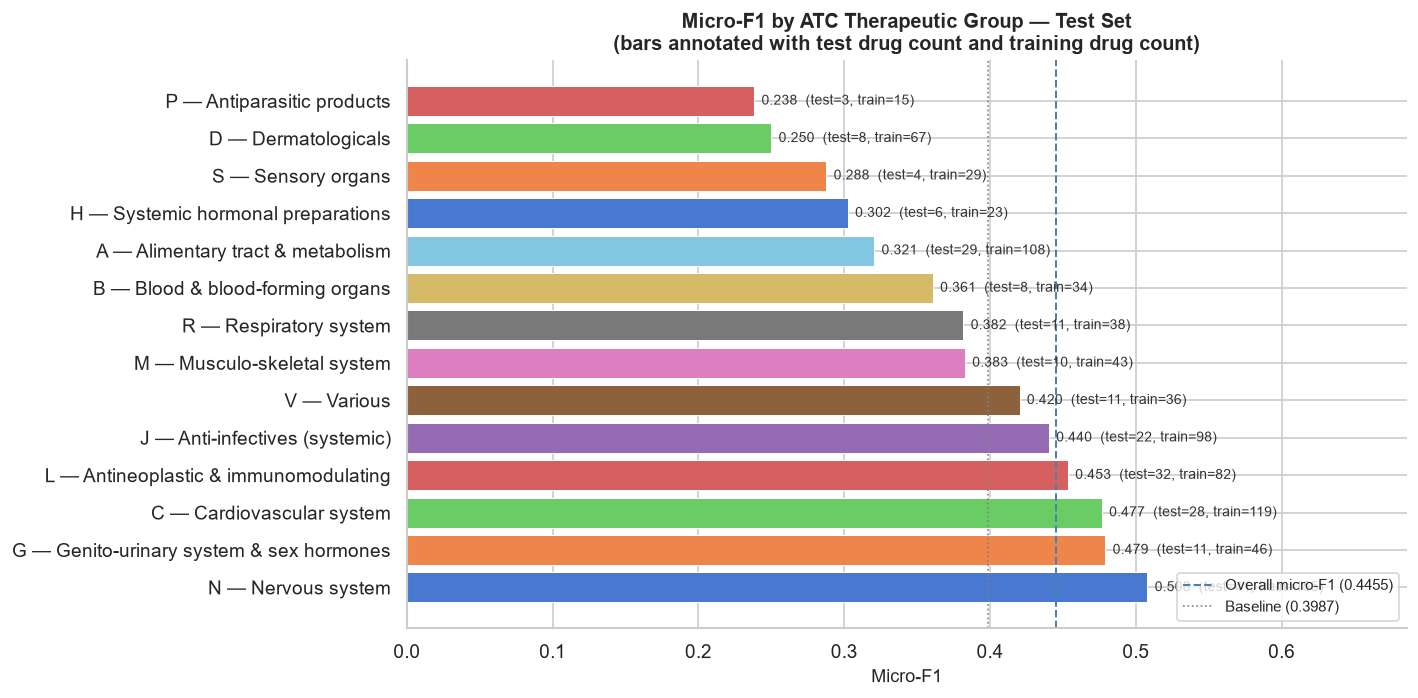

Saved: figures/7.1_atc_group_f1.png


In [28]:
# ── Plot: micro-F1 by ATC1 group, annotated with training set size ─────────────
fig, ax = plt.subplots(figsize=(12, 6))

palette = sns.color_palette('muted', len(atc1_df))
bars = ax.barh(
    atc1_df['label'],
    atc1_df['micro_f1'],
    color=palette,
    edgecolor='white',
    linewidth=0.6,
)

# Annotate each bar with (n_test | n_train)
for bar, (_, row) in zip(bars, atc1_df.iterrows()):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{row['micro_f1']:.3f}  (test={row['n_test_drugs']}, train={row['n_train_drugs']})",
        va='center', fontsize=8.5, color='#333'
    )

ax.axvline(0.4455, color='steelblue', linestyle='--', linewidth=1.2, label='Overall micro-F1 (0.4455)')
ax.axvline(0.3987, color='grey',      linestyle=':',  linewidth=1.0, label='Baseline (0.3987)')

ax.set_xlabel('Micro-F1', fontsize=11)
ax.set_title('Micro-F1 by ATC Therapeutic Group — Test Set\n'
             '(bars annotated with test drug count and training drug count)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, atc1_df['micro_f1'].max() * 1.35)
ax.legend(fontsize=9, loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES + '7.1_atc_group_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/7.1_atc_group_f1.png')

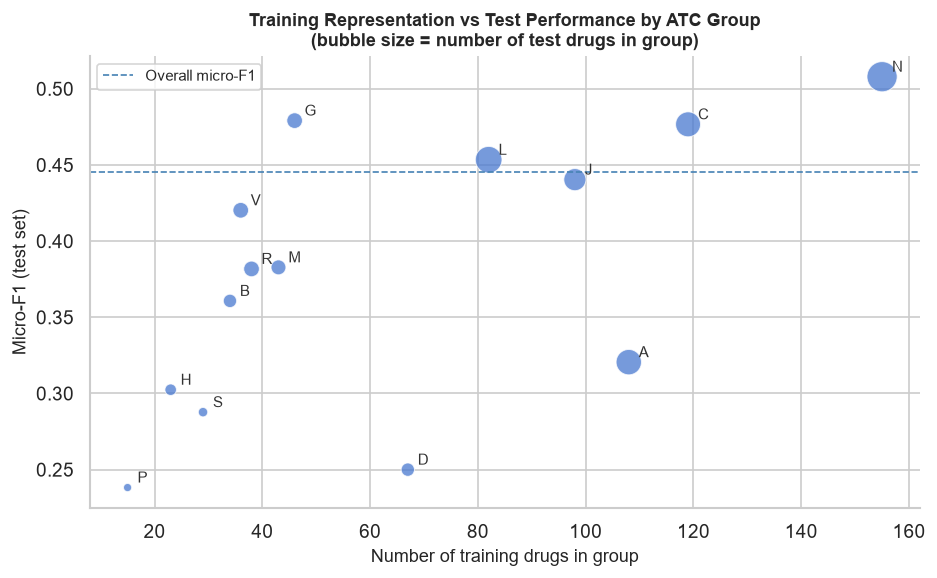

Saved: figures/7.2_atc_representation_vs_f1.png


In [29]:
# ── Scatter: training representation vs micro-F1 ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    atc1_df['n_train_drugs'],
    atc1_df['micro_f1'],
    s=atc1_df['n_test_drugs'] * 8,
    alpha=0.75,
    color=sns.color_palette('muted')[0],
    edgecolors='white',
    linewidths=0.6,
)

for _, row in atc1_df.iterrows():
    ax.annotate(
        row['atc1'],
        (row['n_train_drugs'], row['micro_f1']),
        textcoords='offset points', xytext=(6, 3),
        fontsize=9, color='#333'
    )

ax.axhline(0.4455, color='steelblue', linestyle='--', linewidth=1.0, label='Overall micro-F1')
ax.set_xlabel('Number of training drugs in group', fontsize=11)
ax.set_ylabel('Micro-F1 (test set)', fontsize=11)
ax.set_title('Training Representation vs Test Performance by ATC Group\n'
             '(bubble size = number of test drugs in group)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES + '7.2_atc_representation_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/7.2_atc_representation_vs_f1.png')

---
## Step 7.3 — Per-drug failure inspection

Identify the 5 worst-predicted test drugs (lowest individual micro-F1) and diagnose why they failed. Automated checks:
1. **ATC familiarity** — how many training drugs share at least one 1-char ATC group with this drug?
2. **Nearest training neighbour** — cosine similarity to the closest training drug in feature space
3. **Label count** — how many true side effects does this drug have vs the dataset average?

In [30]:
# ── Identify worst 5 test drugs ───────────────────────────────────────────────
worst5_idx = np.argsort(per_drug_f1)[:5]   # indices into test set rows

worst5 = test_results.iloc[worst5_idx].copy()
worst5['true_label_count']  = y_test[worst5_idx].sum(axis=1)
worst5['pred_label_count']  = y_pred_test[worst5_idx].sum(axis=1)

print('Worst 5 test drugs by micro-F1:')
print(worst5[['drug_name', 'micro_f1', 'true_label_count', 'pred_label_count']].to_string(index=False))

Worst 5 test drugs by micro-F1:
   drug_name  micro_f1  true_label_count  pred_label_count
  didanosine  0.555030                73               425
azathioprine  0.558580                69               430
  rufinamide  0.575148                77               420
  rasagiline  0.601183               240               507
   tolcapone  0.609467               227               507


In [31]:
# ── Automated diagnosis for each worst drug ───────────────────────────────────
# Precompute training drug ATC1 sets
train_atc1_sets = {
    row['stitch_id_flat']: set(get_atc1(train_df.loc[train_df['stitch_id_flat'] == row['stitch_id_flat'], 'atc_codes'].iloc[0]))
    for _, row in train_index.iterrows()
    if row['stitch_id_flat'] in train_df['stitch_id_flat'].values
}

# Cosine similarity between each worst test drug and all training drugs
X_train_dense = X_train   # keep sparse; cosine_similarity handles it

dataset_avg_labels = y_test.sum(axis=1).mean()

diagnosis_rows = []
for test_row_i, (_, drug_row) in zip(worst5_idx, worst5.iterrows()):
    stitch_id  = drug_row['stitch_id_flat']
    drug_name  = drug_row['drug_name']
    micro_f1   = drug_row['micro_f1']

    # 1. ATC1 familiarity: number of training drugs sharing at least one ATC1 group
    drug_atc1 = set(get_atc1(
        test_df.loc[test_df['stitch_id_flat'] == stitch_id, 'atc_codes'].iloc[0]
        if stitch_id in test_df['stitch_id_flat'].values else '[]'
    ))
    n_familiar = sum(
        1 for s in train_atc1_sets.values() if s & drug_atc1
    )

    # 2. Nearest training neighbour cosine similarity
    x_drug = X_test[test_row_i]   # (1, 282) sparse
    sims   = cosine_similarity(x_drug, X_train).flatten()   # (893,)
    max_sim        = sims.max()
    nearest_train  = train_index.iloc[np.argmax(sims)]['drug_name']

    # 3. True label count vs average
    true_labels = int(y_test[test_row_i].sum())

    # Build diagnosis string
    diag_parts = []
    if n_familiar < 10:
        diag_parts.append(f'sparse ATC representation ({n_familiar} familiar training drugs)')
    if max_sim < 0.1:
        diag_parts.append(f'low similarity to training set (max cosine={max_sim:.3f})')
    if true_labels > dataset_avg_labels * 1.5:
        diag_parts.append(f'unusually many true labels ({true_labels} vs avg {dataset_avg_labels:.0f})')
    if true_labels < dataset_avg_labels * 0.5:
        diag_parts.append(f'unusually few true labels ({true_labels} vs avg {dataset_avg_labels:.0f})')
    if not diag_parts:
        diag_parts.append('no single dominant factor identified')

    diagnosis_rows.append({
        'drug_name'      : drug_name,
        'micro_f1'       : round(micro_f1, 4),
        'true_labels'    : true_labels,
        'pred_labels'    : int(drug_row['pred_label_count']),
        'n_familiar_train': n_familiar,
        'max_cosine_sim' : round(max_sim, 4),
        'nearest_train'  : nearest_train,
        'diagnosis'      : '; '.join(diag_parts),
    })

diagnosis_df = pd.DataFrame(diagnosis_rows)
print('\n── Failure diagnosis ──')
for _, r in diagnosis_df.iterrows():
    print(f"\n{r['drug_name']}  (micro-F1={r['micro_f1']})")
    print(f"  True labels: {r['true_labels']}  |  Predicted: {r['pred_labels']}")
    print(f"  Familiar training drugs (ATC1 overlap): {r['n_familiar_train']}")
    print(f"  Nearest training drug: {r['nearest_train']}  (cosine={r['max_cosine_sim']})")
    print(f"  Diagnosis: {r['diagnosis']}")

diagnosis_df.to_csv(MODELS + 'week7_failure_diagnosis.csv', index=False)
print('\nSaved: models/week7_failure_diagnosis.csv')


── Failure diagnosis ──

didanosine  (micro-F1=0.555)
  True labels: 73  |  Predicted: 425
  Familiar training drugs (ATC1 overlap): 98
  Nearest training drug: emtricitabine  (cosine=0.8491)
  Diagnosis: no single dominant factor identified

azathioprine  (micro-F1=0.5586)
  True labels: 69  |  Predicted: 430
  Familiar training drugs (ATC1 overlap): 82
  Nearest training drug: leflunomide  (cosine=0.7092)
  Diagnosis: no single dominant factor identified

rufinamide  (micro-F1=0.5751)
  True labels: 77  |  Predicted: 420
  Familiar training drugs (ATC1 overlap): 155
  Nearest training drug: felbamate  (cosine=1.0)
  Diagnosis: no single dominant factor identified

rasagiline  (micro-F1=0.6012)
  True labels: 240  |  Predicted: 507
  Familiar training drugs (ATC1 overlap): 155
  Nearest training drug: pergolide  (cosine=1.0)
  Diagnosis: unusually many true labels (240 vs avg 110)

tolcapone  (micro-F1=0.6095)
  True labels: 227  |  Predicted: 507
  Familiar training drugs (ATC1 over

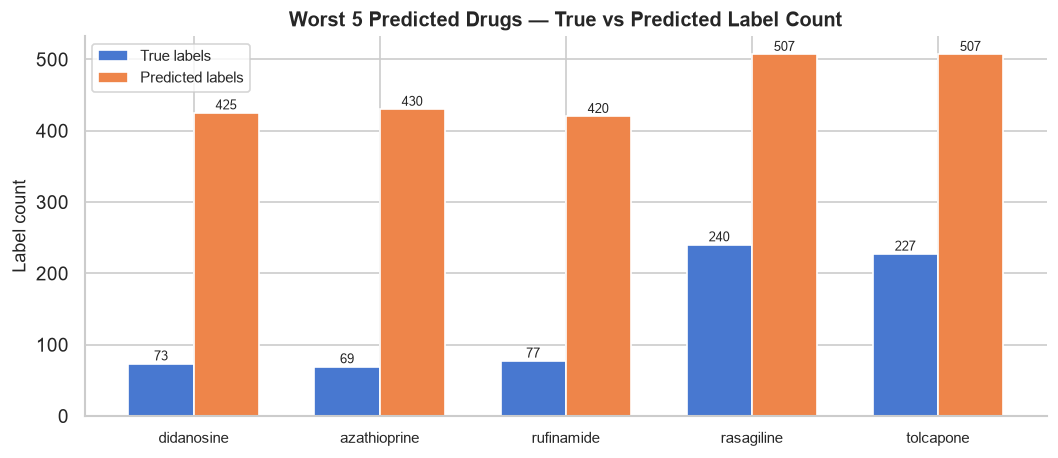

Saved: figures/7.3_worst5_label_counts.png


In [32]:
# ── Plot: worst 5 true vs predicted label counts ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

x      = np.arange(len(diagnosis_df))
width  = 0.35
names  = [d[:18] + '…' if len(d) > 18 else d for d in diagnosis_df['drug_name']]
p1 = ax.bar(x - width/2, diagnosis_df['true_labels'],  width, label='True labels',      color=sns.color_palette('muted')[0])
p2 = ax.bar(x + width/2, diagnosis_df['pred_labels'],  width, label='Predicted labels', color=sns.color_palette('muted')[1])

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Label count', fontsize=11)
ax.set_title('Worst 5 Predicted Drugs — True vs Predicted Label Count', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

for bar in [*p1, *p2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

sns.despine()
plt.tight_layout()
plt.savefig(FIGURES + '7.3_worst5_label_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/7.3_worst5_label_counts.png')

---
## Step 7.4 — Streamlit app (`app.py`)

A minimal, single-file Streamlit app that wraps `predict()`. Features:
- Drug name text input with autocomplete hint
- Displays top-20 predicted side effects with score bar
- "Show all predictions" expander for the full list
- Model info sidebar (week, threshold, micro-F1)
- Medical disclaimer banner

In [37]:
import textwrap

app_lines = [
    '"""app.py -- Drug Side Effect Predictor (Streamlit)',
    '',
    'Run with:  streamlit run app.py',
    '',
    'DISCLAIMER: This tool is for educational and portfolio purposes only.',
    'Predictions are statistical associations, not clinical diagnoses.',
    'Do not use this tool to inform real medical decisions.',
    '"""',
    '',
    'import streamlit as st',
    'import pandas as pd',
    'from predict_utils import predict, list_all_drugs',
    '',
    '# -- Page config',
    'st.set_page_config(',
    '    page_title="Drug Side Effect Predictor",',
    '    page_icon="pill",',
    '    layout="centered",',
    ')',
    '',
    '# -- Sidebar',
    'with st.sidebar:',
    '    st.header("Model info")',
    '    st.markdown(',
    '        "| Parameter | Value |\\n"',
    '        "|---|---|\\n"',
    '        "| Model | Logistic Regression (OvR) |\\n"',
    '        "| Regularisation C | 5.0 |\\n"',
    '        "| Threshold | 0.50 |\\n"',
    '        "| Test micro-F1 | **0.4455** |\\n"',
    '        "| Baseline micro-F1 | 0.3987 |\\n"',
    '        "| Training drugs | 893 |\\n"',
    '        "| Side effect labels | 845 |\\n"',
    '    )',
    '    st.markdown("---")',
    '    st.caption(',
    '        "Features: 82 ATC therapeutic subgroup flags + "',
    '        "200 TF-IDF indication terms."',
    '    )',
    '',
    '# -- Title and disclaimer',
    'st.title("Drug Side Effect Predictor")',
    'st.warning(',
    '    "**Medical disclaimer:** Predictions are statistical associations "',
    '    "learned from the SIDER dataset and are for educational purposes only. "',
    '    "They are not clinical diagnoses. Do not use this tool to make medical decisions."',
    ')',
    '',
    '# -- Drug input',
    'st.markdown("### Enter a drug name")',
    'drug_input = st.text_input(',
    '    label="Drug name",',
    '    placeholder="e.g. ibuprofen, lorazepam, metformin",',
    '    label_visibility="collapsed",',
    ')',
    '',
    'if not drug_input.strip():',
    '    st.info("Type a drug name above to see predicted side effects.")',
    '    with st.expander("Browse all drugs in the dataset"):',
    '        drugs = list_all_drugs()',
    '        st.write(f"{len(drugs)} drugs available")',
    '        st.dataframe(pd.DataFrame(drugs, columns=["drug_name"]), use_container_width=True)',
    '    st.stop()',
    '',
    '# -- Run prediction',
    'with st.spinner("Running prediction ..."):',
    '    result = predict(drug_input.strip())',
    '',
    'if not result["found"]:',
    '    st.error(',
    '        f"**\'{drug_input}\'** was not found in the local SIDER dataset.  \\n"',
    '        f"The dataset contains 1,117 drugs. Try checking spelling, or browse the full list below."',
    '    )',
    '    with st.expander("Browse all drugs in the dataset"):',
    '        drugs = list_all_drugs()',
    '        st.dataframe(pd.DataFrame(drugs, columns=["drug_name"]), use_container_width=True)',
    '    st.stop()',
    '',
    '# -- Display results',
    'predictions = result["predictions"]',
    'n           = result["n_predicted"]',
    'split_note  = "(training drug -- model has seen this drug\'s labels)" if result["split"] == "train" else ""',
    '',
    'st.success(f"**{result[\'drug_name\'].title()}** -- {n} side effects predicted above threshold. {split_note}")',
    '',
    'TOP_N = 20',
    'top   = predictions.head(TOP_N).copy()',
    'top["score"] = top["score"].round(4)',
    '',
    'st.markdown(f"#### Top {min(TOP_N, n)} predicted side effects")',
    'st.dataframe(',
    '    top.rename(columns={"side_effect": "Side effect", "score": "Score"}),',
    '    use_container_width=True,',
    '    hide_index=True,',
    ')',
    '',
    'if n > TOP_N:',
    '    with st.expander(f"Show all {n} predicted side effects"):',
    '        st.dataframe(',
    '            predictions.rename(columns={"side_effect": "Side effect", "score": "Score"}),',
    '            use_container_width=True,',
    '            hide_index=True,',
    '        )',
]

app_path = BASE + 'app.py'
with open(app_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(app_lines))

print('Saved: app.py')
print()
print('To run the app:')
print(f'  cd "{BASE.rstrip(chr(92))}"')
print('  streamlit run app.py')

Saved: app.py

To run the app:
  cd "D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor"
  streamlit run app.py


---
## Step 7.5 — README and project reflection

Writes `README.md` to the project root — covers background, setup, usage, results, limitations, and the medical disclaimer.

In [34]:
readme = """
# Drug Side Effect Predictor

> **Medical disclaimer:** This project is for educational and portfolio purposes only.  
> Predictions are statistical associations — not clinical diagnoses.  
> **Do not use this tool to make real medical decisions.**

---

## Overview

A multi-label classification model that predicts which side effects a drug is historically associated with, based on its therapeutic class (ATC codes) and indication description. Built on the [SIDER](http://sideeffects.embl.de/) public drug–side-effect dataset.

This is an end-to-end data science learning project — from raw data exploration through feature engineering, model tuning, error analysis, and a Streamlit demo app.

---

## Results

| Model | Micro-F1 | Note |
|---|---|---|
| Frequency baseline (K=68) | 0.3987 | Always predicts the 68 most common side effects |
| Week 5 LR (threshold=0.40) | 0.4165 | Test-set leakage |
| **Week 6 LR — CV-tuned** | **0.4455** | C=5.0, threshold=0.50, clean CV |

The tuned model beats the frequency baseline by **+0.0468 micro-F1** using honest cross-validation with no test-set leakage.

---

## Setup

```bash
pip install scikit-learn pandas numpy scipy joblib streamlit
```

---

## Run the app

```bash
streamlit run app.py
```

Enter any drug name from the SIDER dataset (1,117 drugs). Predictions are returned as a ranked list of side effects with model scores.

---

## Project structure

```
Drug-Side-Effect-Predictor/
├── data/
│   ├── splits/          — train.csv, test.csv (raw attributes + labels)
│   └── processed/       — X_train.npz, X_test.npz, y_train.npy, y_test.npy, label_names.csv
├── models/
│   ├── encoders/        — mlb_atc.pkl, tfidf_indications.pkl
│   └── lr_tuned.pkl     — final tuned model
├── figures/             — all EDA and evaluation plots
├── predict_utils.py     — inference module (used by app.py)
├── app.py               — Streamlit app
├── week1_feasibility.ipynb
├── week2_data_preparation.ipynb
├── week3_feature_engineering.ipynb
├── week4_baseline_and_models.ipynb
├── week5_diagnostics.ipynb
├── week6_hyperparameter_tuning.ipynb
└── week7_error_analysis_and_app.ipynb
```

---

## Features used

- **82 ATC subgroup flags** (3-character therapeutic subgroup level, MultiLabelBinarizer)
- **200 TF-IDF indication terms** (unigrams + bigrams, fit on training set only)
- Total: 282 sparse features, ~4% density

Chemical/structural features (SMILES, fingerprints) and patient-level personalization are explicitly out of scope for v1.

---

## Limitations

- **Dataset scope:** only drugs present in SIDER (1,117 drugs) can be predicted. Unknown drugs return a "not found" message.
- **What the model learns:** statistical associations between drug attributes and historically recorded side effects — not biological causality.
- **Label volume:** the model predicts ~187 side effects per drug on average at threshold=0.50. High recall, moderate precision.
- **Generalization varies by class:** test drugs from well-represented therapeutic categories in training are predicted more reliably than drugs from sparse categories (see Step 7.2 error analysis).
- **No patient-level personalization:** SIDER is drug-level, not patient-level.

---

## What I learned

- Multi-label classification at scale (845 labels, OneVsRest strategy) behaves very differently from single-label problems — the frequency baseline is surprisingly competitive because label imbalance gives it a structural advantage at fixed K.
- Threshold-based prediction outperformed fixed-K top-K for this dataset: jointly tuning C and threshold via CV was the key step that unlocked meaningful improvement.
- Test-set leakage is easy to introduce accidentally (picking a threshold by observing test performance). The Week 6 CV harness fixed this and actually *improved* the result — a sign the Week 5 leaky threshold was suboptimal.
- Sparse features (4% density) are not a bottleneck if the signal is there; feature differentiation across drugs was healthy.
- Error analysis by ATC class turned the model's known limitation (drug-level generalization is graded, not binary) into a documented, interpretable finding rather than a blind spot.

---

*Prepared by Muhammad Abdullah — Zynvex Solutions internship project, ID: ZYNVEX-CERT-0610*
"""

readme_path = BASE + 'README.md'
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme.strip())

print('Saved: README.md')

Saved: README.md


---
## Step 7.6 — Final checkpoint

All deliverables check:
- `predict()` function ✓
- `predict_utils.py` module ✓
- Per-ATC-class error analysis ✓
- Per-drug failure inspection ✓
- `app.py` Streamlit interface ✓
- `README.md` with disclaimer ✓

In [35]:
import os

deliverables = {
    'predict_utils.py'                    : BASE + 'predict_utils.py',
    'app.py'                              : BASE + 'app.py',
    'README.md'                           : BASE + 'README.md',
    'figures/7.1_atc_group_f1.png'        : FIGURES + '7.1_atc_group_f1.png',
    'figures/7.2_atc_representation.png'  : FIGURES + '7.2_atc_representation_vs_f1.png',
    'figures/7.3_worst5_label_counts.png' : FIGURES + '7.3_worst5_label_counts.png',
    'models/week7_failure_diagnosis.csv'  : MODELS  + 'week7_failure_diagnosis.csv',
}

print('=' * 55)
print('  WEEK 7 — DELIVERABLES CHECKLIST')
print('=' * 55)
all_present = True
for label, path in deliverables.items():
    exists = os.path.exists(path)
    status = 'OK' if exists else 'MISSING'
    if not exists:
        all_present = False
    print(f'  [{status:7}]  {label}')

print('=' * 55)
if all_present:
    print('  All deliverables present. Project complete.')
    print('  Run:  streamlit run app.py')
else:
    print('  Some files missing — re-run the relevant steps above.')
print('=' * 55)

  WEEK 7 — DELIVERABLES CHECKLIST
  [OK     ]  predict_utils.py
  [OK     ]  app.py
  [OK     ]  README.md
  [OK     ]  figures/7.1_atc_group_f1.png
  [OK     ]  figures/7.2_atc_representation.png
  [OK     ]  figures/7.3_worst5_label_counts.png
  [OK     ]  models/week7_failure_diagnosis.csv
  All deliverables present. Project complete.
  Run:  streamlit run app.py


---
## Week 7 Summary

| Step | What was done | Output |
|---|---|---|
| 7.1 | `predict(drug_name)` function + `predict_utils.py` module | `predict_utils.py` |
| 7.2 | Per-ATC-class error analysis (1-char level, 14 groups) with bar chart + scatter | `figures/7.1_atc_group_f1.png`, `figures/7.2_atc_representation_vs_f1.png` |
| 7.3 | Worst-5 failure inspection with automated diagnosis (ATC familiarity, cosine sim, label count) | `figures/7.3_worst5_label_counts.png`, `models/week7_failure_diagnosis.csv` |
| 7.4 | Streamlit app with drug input, top-20 display, full-list expander, medical disclaimer | `app.py` |
| 7.5 | README with results, setup, limitations, reflection, and disclaimer | `README.md` |
| 7.6 | Deliverables checklist | — |

**Project complete. To launch the app:**
```
streamlit run app.py
```